# MODEL TRAINING AND COMPARISON

Day-ahead (48 half-hours ahead) forecasting of GB national demand with LSTM, XGBoost and
multiple linear regression (MLR), each trained on the full feature set and, for LSTM and
XGBoost, on a feature subset chosen by binary MRFO. Models are scored on the whole test set
(last 20% of the data) and compared with Wilcoxon and Diebold-Mariano tests.

## SETUP AND DATA LOADING

In [ ]:
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import wilcoxon

from energy_forecast.models.lstm_model import LSTM, prepare_lstm_data, train_model, get_train_predictions, predict_test_set

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import mlflow

mlflow.set_experiment("energy-demand-forecasting")

In [ ]:
# Hyperparameters LSTM
hidden_size = 64
num_layers = 2
output_size = 1
num_epochs = 10
learning_rate = 0.001
batch_size = 336
seq_length = 48
# criterion = nn.SmoothL1Loss(beta=1.0)
criterion = nn.MSELoss()

In [ ]:
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

In [6]:
full = pd.read_csv("data/processed/model_ready_features_day_ahead.csv", index_col=0, parse_dates=True)

## Evaluation helper

Every model is scored on the **entire test set** (last 20% of the data, Feb 2021 – Feb 2024),
not just its first week. Besides overall MAE/RMSE, RMSE is also computed per calendar week, to
show how stable each model is across seasons, holidays and years.

In [ ]:
def evaluate(y_true, y_pred, index):
    """Score predictions over the whole test set; returns metrics plus timestamped errors."""
    errors = pd.Series(np.asarray(y_true).flatten() - np.asarray(y_pred).flatten(), index=index)

    weekly = (errors ** 2).resample("W").agg(["mean", "count"])
    # Drop partial weeks at the start/end of the test period (a full week is 336 half-hours;
    # the threshold leaves room for clock-change weeks and small gaps)
    weekly = weekly[weekly["count"] >= 300]

    return {
        "errors": errors,
        "mae_test": float(errors.abs().mean()),
        "rmse_test": float(np.sqrt((errors ** 2).mean())),
        "weekly_rmse": np.sqrt(weekly["mean"]),
    }

## Manta Ray Feature Optimisation (MRFO)

#### Feature selection

MRFO feature selection only sees the training portion (first 80%) of the data. Inside each
fitness evaluation, that portion is split again into an inner training set (first 80% of it)
and a validation set (last 20% of it), and candidate feature subsets are scored on the
validation set. The test set (last 20%) is never used during selection, so it stays unseen
until final evaluation. The selected features are then trained on the entire training set,
as for the other data sets.

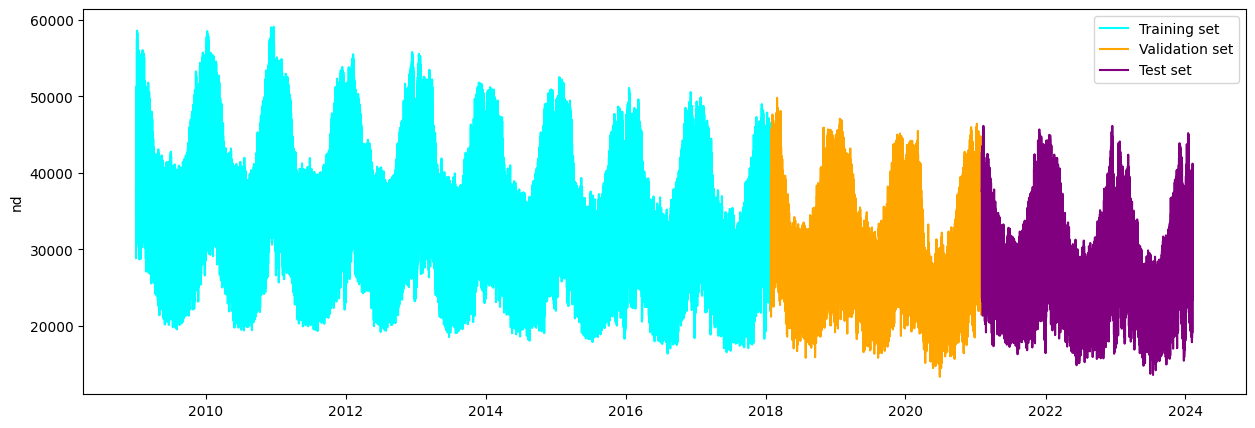

In [ ]:
# Mirrors the splits used below: outer 80/20 train/test, then MRFO's inner 80/20 train/validation
train_end = int(0.8 * len(full))
val_start = int(0.8 * train_end)

plt.plot(full.index[:val_start], full['nd'].iloc[:val_start], color='cyan', label='MRFO training set')
plt.plot(full.index[val_start:train_end], full['nd'].iloc[val_start:train_end], color='orange', label='MRFO validation set')
plt.plot(full.index[train_end:], full['nd'].iloc[train_end:], color='purple', label='Test set (unseen by MRFO)')

plt.ylabel('National Demand (nd)')
plt.title('Train / Validation / Test Split')
plt.legend()
plt.show()

#### Binary MRFO

Feature subsets are searched with binary Manta Ray Foraging Optimization (Zhao, Zhang & Wang,
2020). Each manta ray has a continuous position in [0, 1] per feature, and a feature is selected
when its coordinate is above 0.5. Every iteration, each ray does either **chain foraging** (moving
towards the ray in front and the best solution) or **cyclone foraging** (spiralling around a
random point early on for exploration, and around the best solution later for exploitation). All
rays then do **somersault foraging** around the best solution.

Subsets are scored by an objective to minimise:

$$\text{objective} = 0.99 \cdot \frac{\text{validation MSE}}{\operatorname{Var}(y_{\text{val}})} + 0.01 \cdot \frac{n_{\text{selected}}}{n_{\text{features}}}$$

The small feature-count penalty makes MRFO drop features that don't improve validation error.
Scores are cached per subset (each subset is trained once), and the LSTM fitness is seeded, so
the same subset always gets the same score.

In [ ]:
from energy_forecast.features.mrfo import (
    manta_ray_foraging_optimization,
    random_search,
    xgboost_fitness_function,
    lstm_fitness_function,
)

X = full.drop(columns=['nd'])
y = full['nd']

# Only the training portion goes into MRFO; the fitness functions split off their own
# validation set from it, so the test set is never used to choose features
X_mrfo, _, y_mrfo, _ = train_test_split(X, y, test_size=0.2, shuffle=False)

# Same budget for both fitness functions, so differences in the selected subsets come from
# the model rather than the search effort (10 x 10 keeps the LSTM search affordable)
MRFO_ITERATIONS = 10
MRFO_RAYS = 10

mrfo_xgb = manta_ray_foraging_optimization(
    X_mrfo, y_mrfo, fitness_function=xgboost_fitness_function,
    num_iterations=MRFO_ITERATIONS, num_manta_rays=MRFO_RAYS, random_state=42,
)
selected_columns_xgb = X.columns[np.where(mrfo_xgb.best_mask == 1)[0]]
print("XGBoost-MRFO selected:", list(selected_columns_xgb))

mrfo_lstm = manta_ray_foraging_optimization(
    X_mrfo, y_mrfo, fitness_function=lstm_fitness_function,
    num_iterations=MRFO_ITERATIONS, num_manta_rays=MRFO_RAYS, random_state=42, num_epochs=5,
)
selected_columns_lstm = X.columns[np.where(mrfo_lstm.best_mask == 1)[0]]
print("LSTM-MRFO selected:", list(selected_columns_lstm))

In [ ]:
xgb_mrfo = full[list(selected_columns_xgb) + ['nd']]
lstm_mrfo = full[list(selected_columns_lstm) + ['nd']]

#### Convergence and random-search baseline

To check that MRFO is actually optimising, the XGBoost-fitness search is compared with random
search given the same number of objective evaluations. (The LSTM search is too expensive to
repeat as a random baseline, so only its convergence curve is shown.)

In [ ]:
random_xgb = random_search(
    X_mrfo, y_mrfo, fitness_function=xgboost_fitness_function,
    num_evaluations=len(mrfo_xgb.history), random_state=42,
)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(mrfo_xgb.history, label=f"MRFO ({mrfo_xgb.n_unique_evaluations} unique subsets)")
axs[0].plot(random_xgb.history, label=f"Random search ({random_xgb.n_unique_evaluations} unique subsets)")
axs[0].set_title("XGBoost fitness: best objective so far")
axs[0].set_xlabel("Objective evaluations")
axs[0].set_ylabel("Objective (lower is better)")
axs[0].legend()

axs[1].plot(mrfo_lstm.history, color="teal", label=f"MRFO ({mrfo_lstm.n_unique_evaluations} unique subsets)")
axs[1].set_title("LSTM fitness: best objective so far")
axs[1].set_xlabel("Objective evaluations")
axs[1].set_ylabel("Objective (lower is better)")
axs[1].legend()

plt.tight_layout()
plt.show()

# MODEL TRAINING

# Training

### CLASSIC LSTM

Epoch 1/10. Loss: 0.00500.
Epoch 2/10. Loss: 0.00084.
Epoch 3/10. Loss: 0.00057.
Epoch 4/10. Loss: 0.00044.
Epoch 5/10. Loss: 0.00035.
Epoch 6/10. Loss: 0.00030.
Epoch 7/10. Loss: 0.00027.
Epoch 8/10. Loss: 0.00023.
Epoch 9/10. Loss: 0.00021.
Epoch 10/10. Loss: 0.00020.


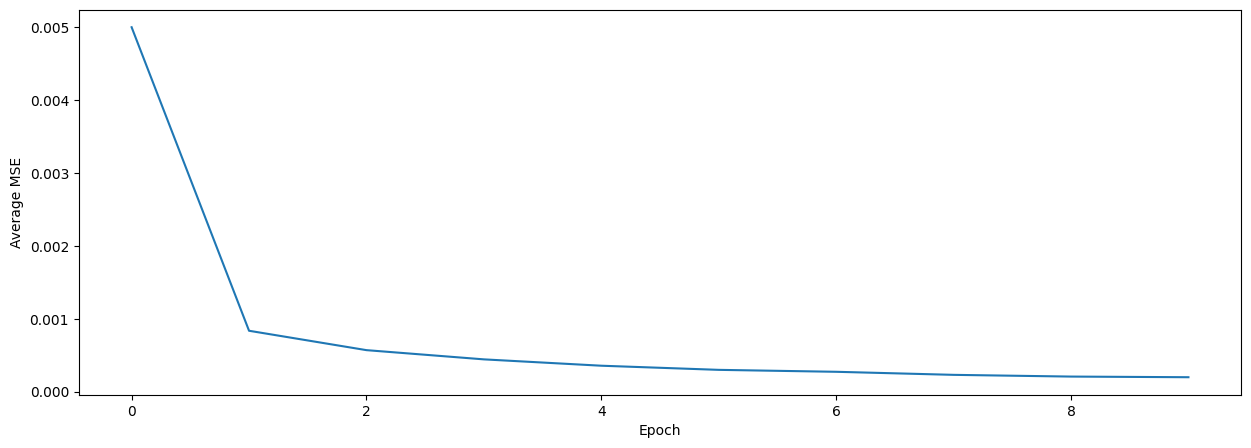

Epoch 1/10. Loss: 0.00734.
Epoch 2/10. Loss: 0.00289.
Epoch 3/10. Loss: 0.00260.
Epoch 4/10. Loss: 0.00246.
Epoch 5/10. Loss: 0.00239.
Epoch 6/10. Loss: 0.00234.
Epoch 7/10. Loss: 0.00231.
Epoch 8/10. Loss: 0.00230.
Epoch 9/10. Loss: 0.00225.
Epoch 10/10. Loss: 0.00225.


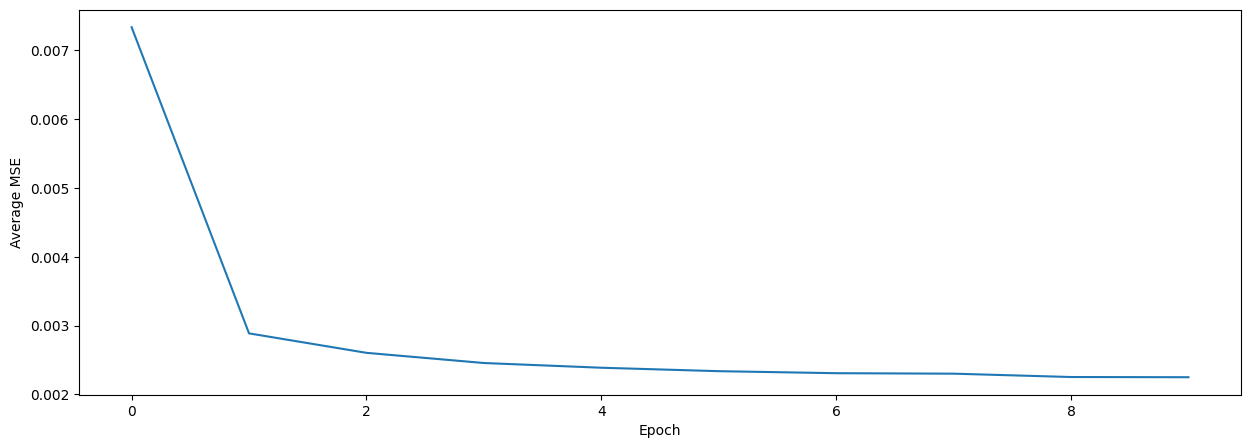

Epoch 1/10. Loss: 0.01417.
Epoch 2/10. Loss: 0.00548.
Epoch 3/10. Loss: 0.00499.
Epoch 4/10. Loss: 0.00474.
Epoch 5/10. Loss: 0.00462.
Epoch 6/10. Loss: 0.00461.
Epoch 7/10. Loss: 0.00457.
Epoch 8/10. Loss: 0.00446.
Epoch 9/10. Loss: 0.00454.
Epoch 10/10. Loss: 0.00466.


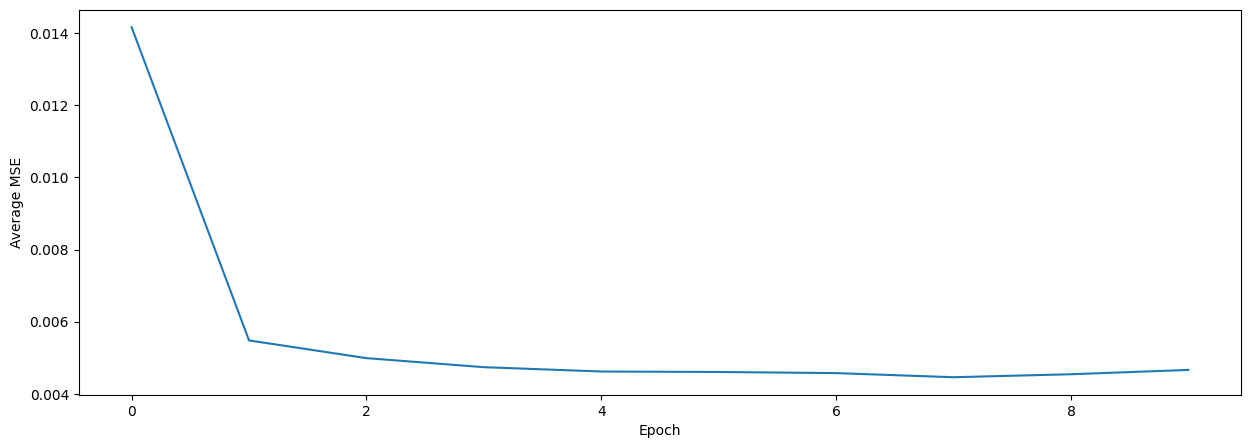

Epoch 1/10. Loss: 0.01130.
Epoch 2/10. Loss: 0.00475.
Epoch 3/10. Loss: 0.00415.
Epoch 4/10. Loss: 0.00384.
Epoch 5/10. Loss: 0.00361.
Epoch 6/10. Loss: 0.00348.
Epoch 7/10. Loss: 0.00336.
Epoch 8/10. Loss: 0.00327.
Epoch 9/10. Loss: 0.00317.
Epoch 10/10. Loss: 0.00313.


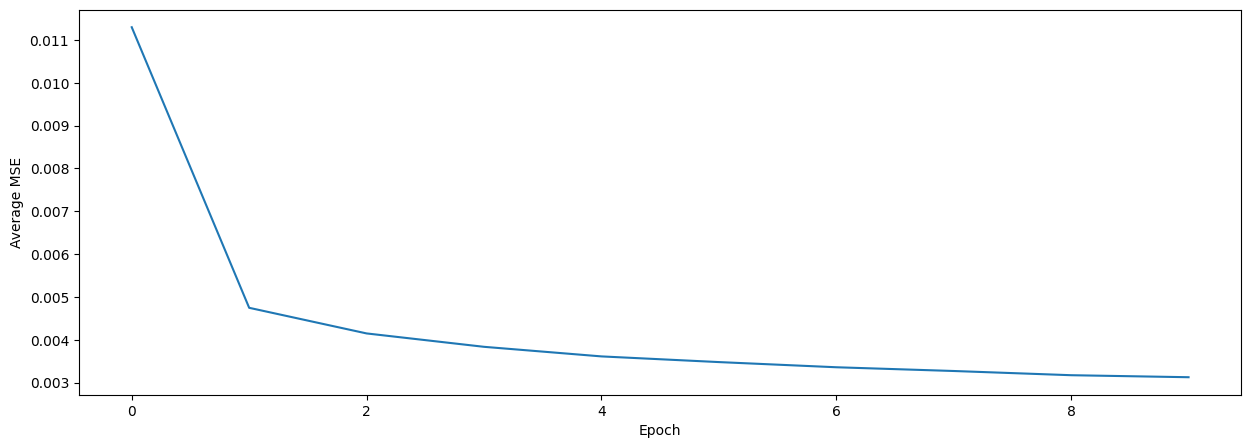

Epoch 1/10. Loss: 0.00715.
Epoch 2/10. Loss: 0.00198.
Epoch 3/10. Loss: 0.00130.
Epoch 4/10. Loss: 0.00109.
Epoch 5/10. Loss: 0.00092.
Epoch 6/10. Loss: 0.00078.
Epoch 7/10. Loss: 0.00068.
Epoch 8/10. Loss: 0.00060.
Epoch 9/10. Loss: 0.00052.
Epoch 10/10. Loss: 0.00047.


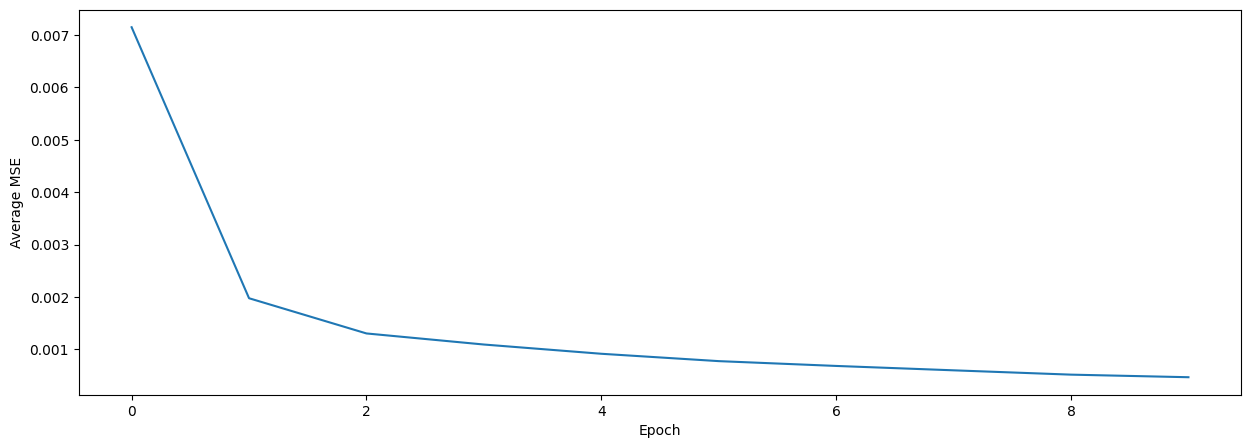

In [ ]:
lstm_data_configs = {
    "full": full,
    "mrfo_lstm": lstm_mrfo,
}

results = {}

for config_name, data in lstm_data_configs.items():
    X = data.drop(columns=["nd"])
    y = data["nd"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    train_loader, test_loader, x_scaler, y_scaler, y_train_arr, y_test_arr = prepare_lstm_data(
        X_train, X_test, y_train, y_test, seq_length, batch_size
    )

    with mlflow.start_run(run_name=f"lstm_{config_name}") as run:
        mlflow.log_params({
            "model_type": "LSTM",
            "feature_set": config_name,
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "num_epochs": num_epochs,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "seq_length": seq_length,
            "n_features": X_train.shape[1],
        })

        model = LSTM(X_train.shape[1], hidden_size, num_layers, output_size).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        trained_model, loss = train_model(model, train_loader, criterion, optimizer, num_epochs)

        for epoch, epoch_loss in enumerate(loss):
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)
        
        mlflow.pytorch.log_model(trained_model, "model")

        results[config_name] = {
            "train_loader": train_loader,
            "test_loader": test_loader,
            "y_scaler": y_scaler,
            "y_train": y_train_arr,
            "y_test": y_test_arr,
            "test_index": X_test.index,
            "loss": loss,
            "trained_model": trained_model,
            "mlflow_run_id": run.info.run_id,
        }

Training predictions for hourly
Mean Training MAE over all sequences: 2269.7973379642976
Mean Training RMSE over all sequences: 3116.200903102866


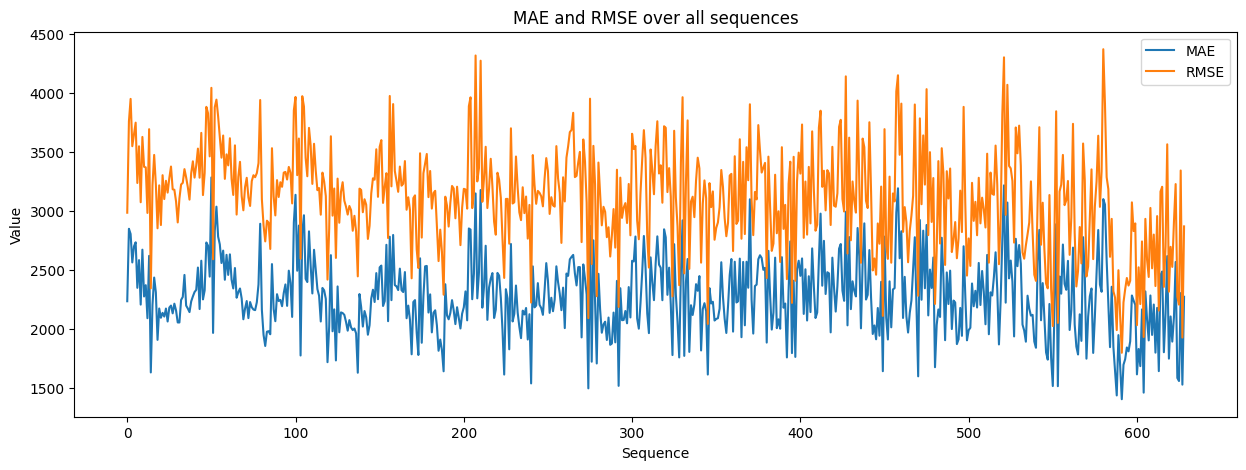

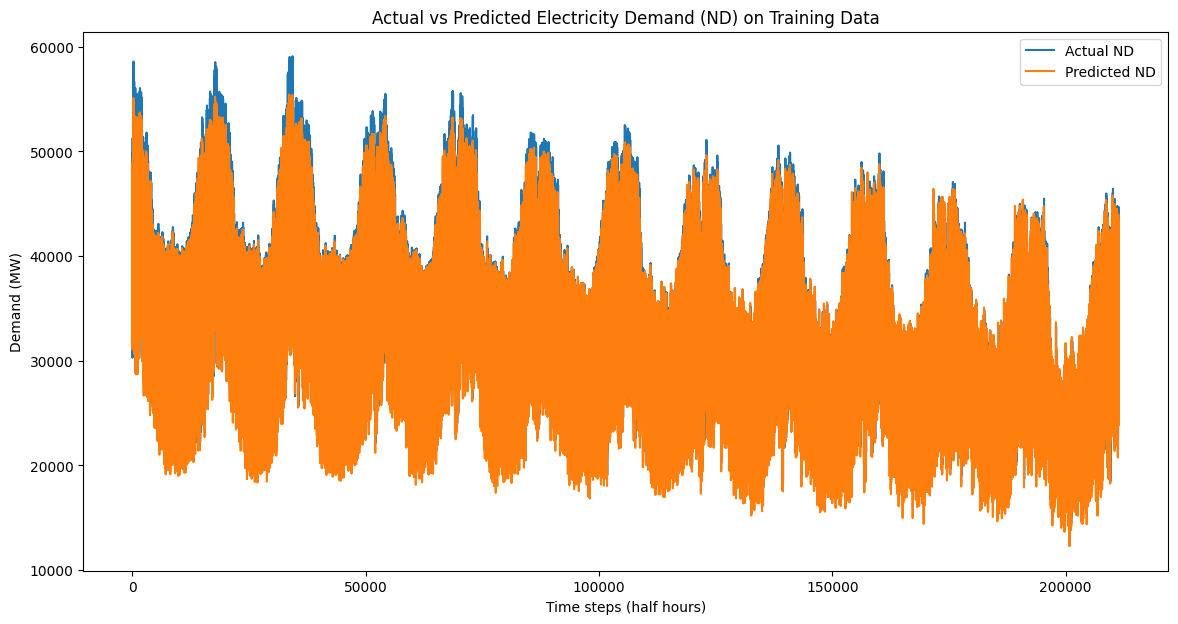

Mean Training MAE and RMSE over first week: 2236.169009254092, 2985.992462928011
Mean Training MAE and RMSE over last week: 2273.975830078125, 2870.10562907951


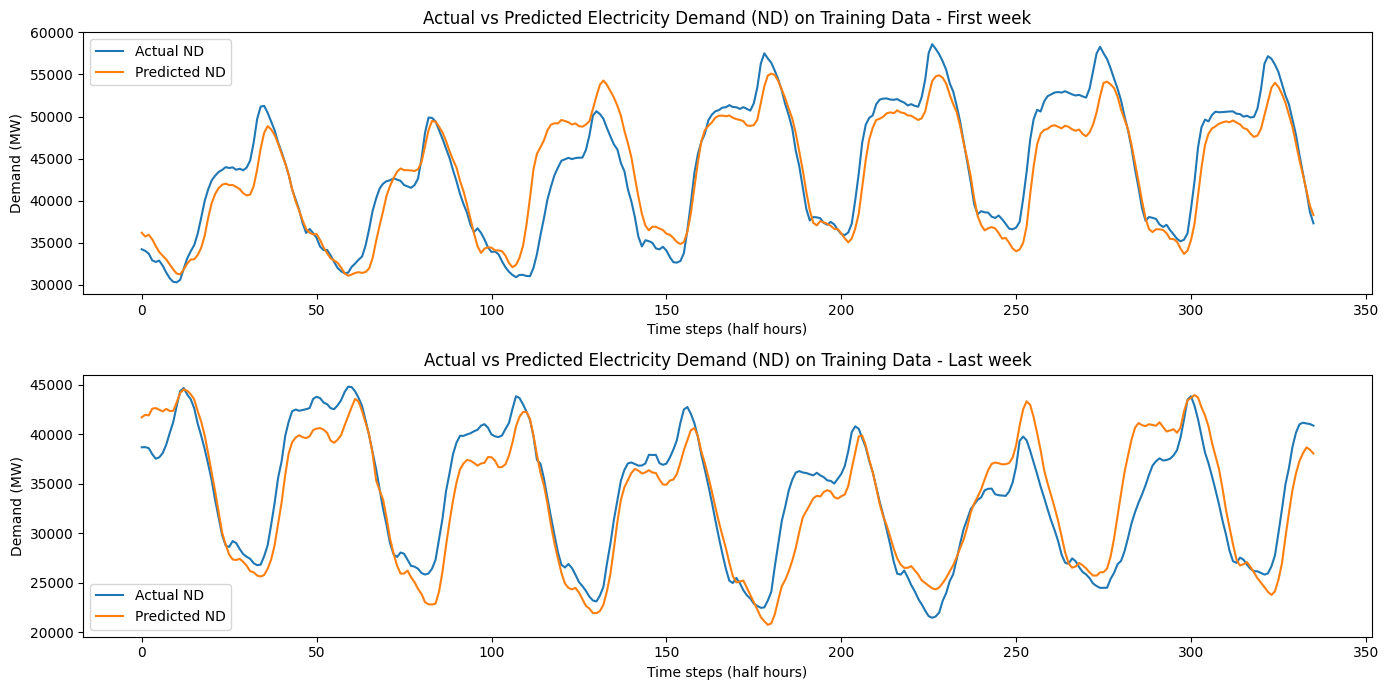

Training predictions for daily
Mean Training MAE over all sequences: 1861.5423193189063
Mean Training RMSE over all sequences: 2408.5679987246936


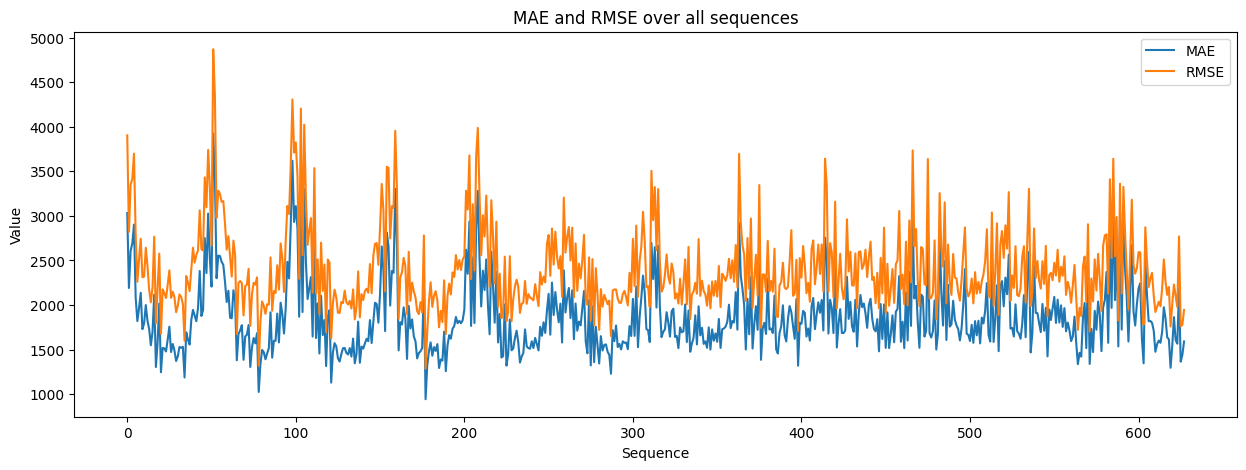

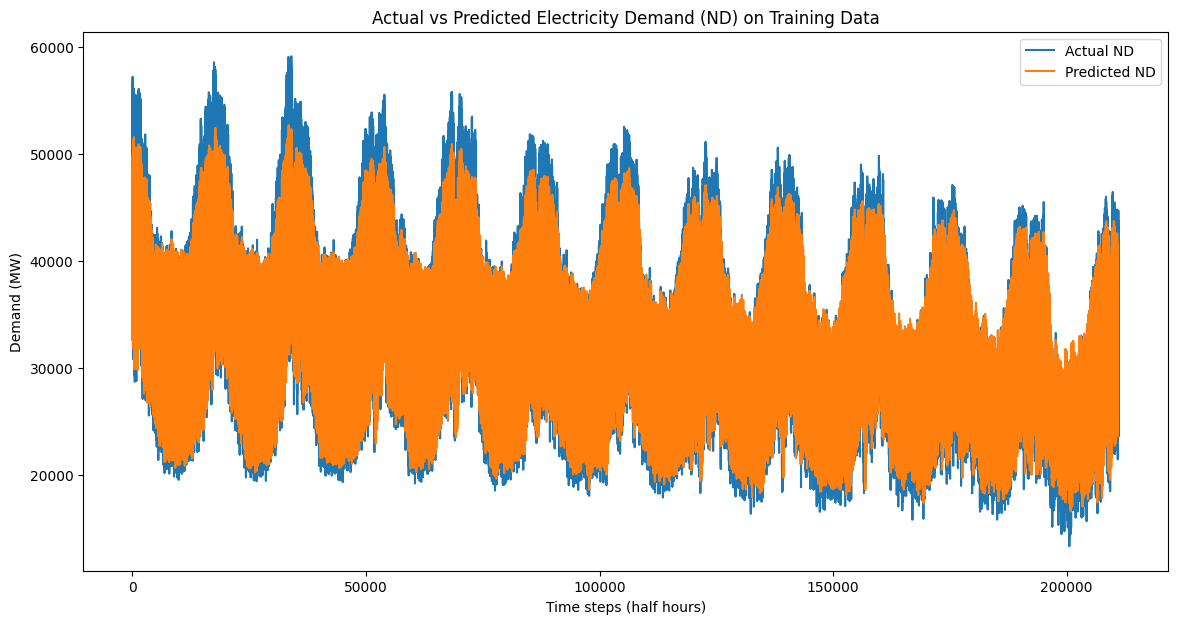

Mean Training MAE and RMSE over first week: 3032.2784540085568, 3904.3218450120107
Mean Training MAE and RMSE over last week: 1590.3641183035713, 1943.869632835885


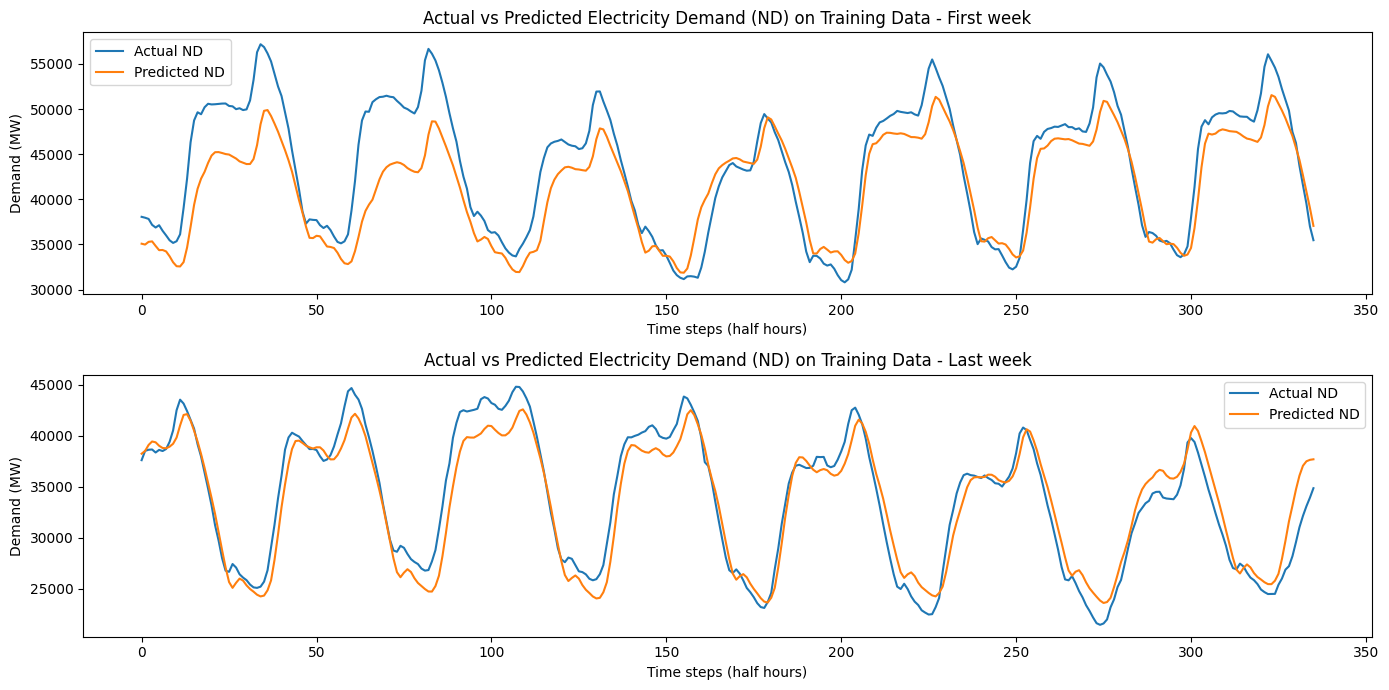

Training predictions for yearly
Mean Training MAE over all sequences: 2849.820838901271
Mean Training RMSE over all sequences: 3558.9559517401326


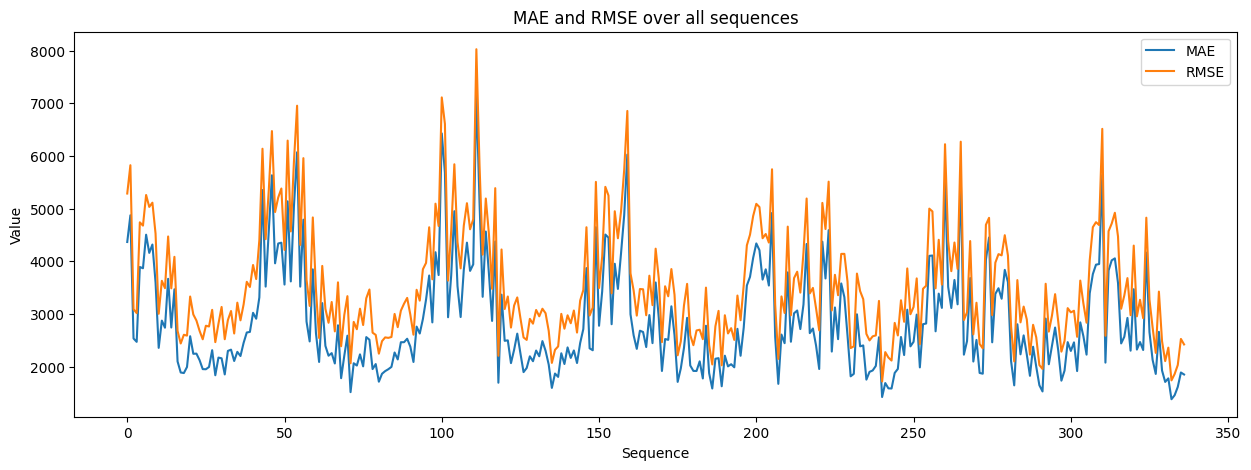

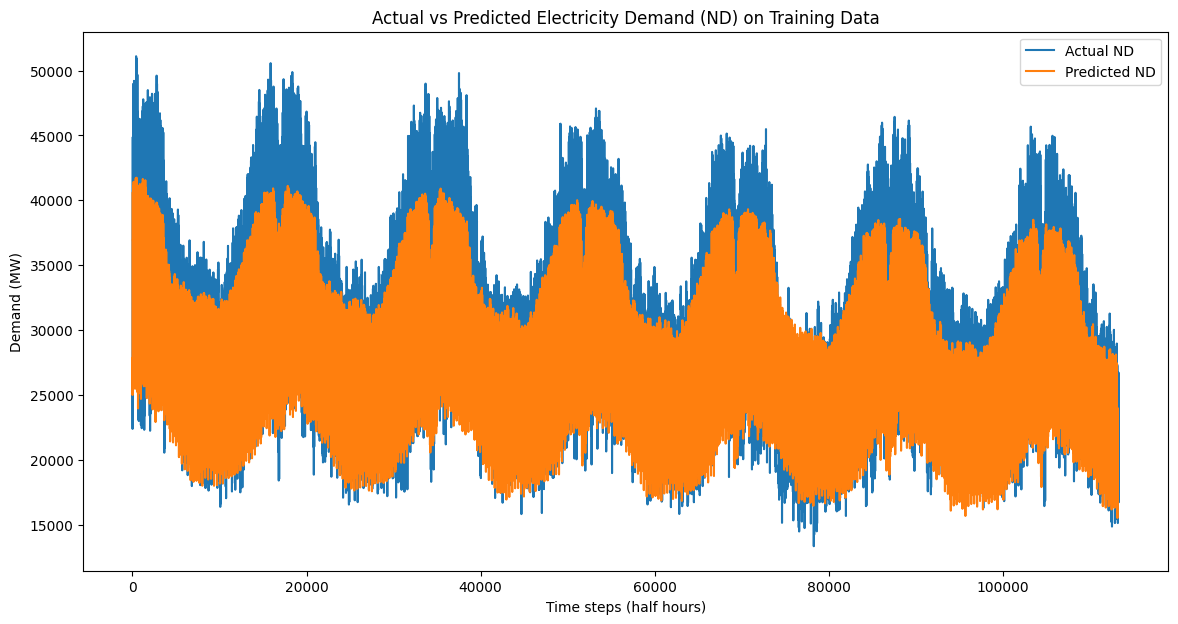

Mean Training MAE and RMSE over first week: 4367.460338774182, 5287.139146436764
Mean Training MAE and RMSE over last week: 1852.8631359281994, 2423.201288426785


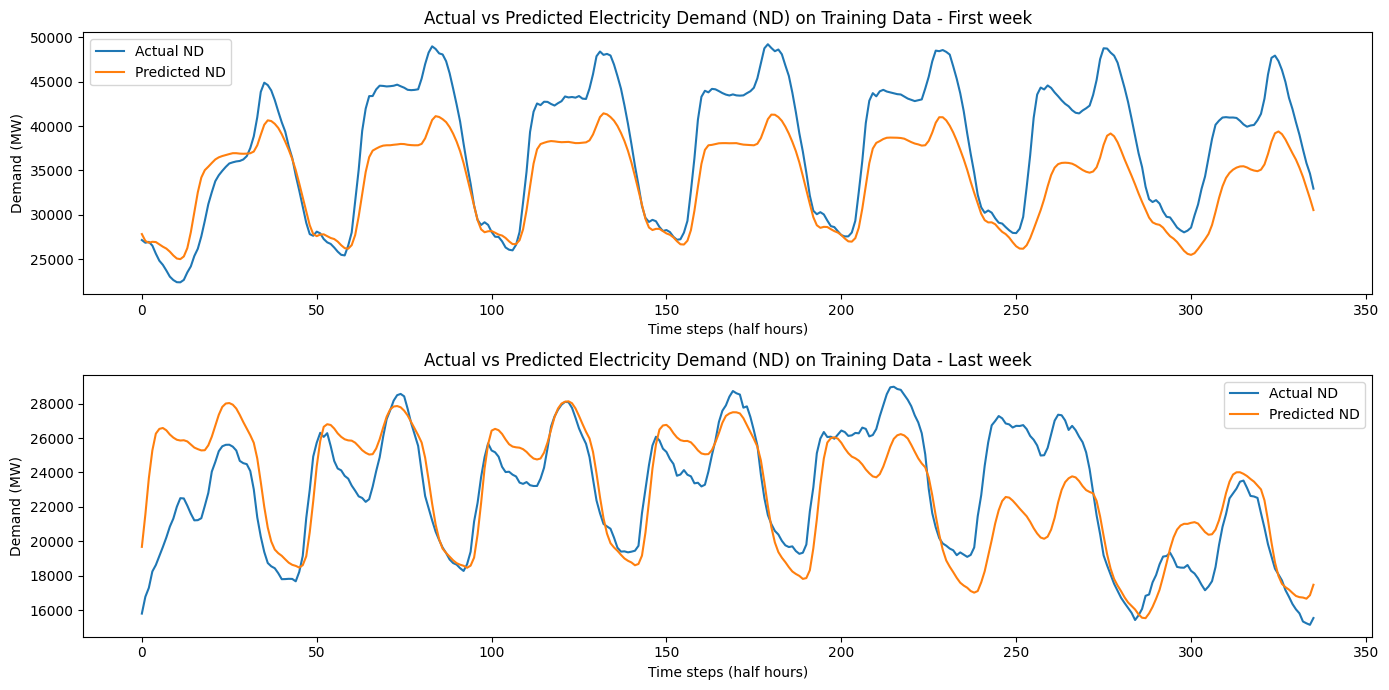

Training predictions for daily_yearly
Mean Training MAE over all sequences: 1957.1114429852812
Mean Training RMSE over all sequences: 2531.447913227442


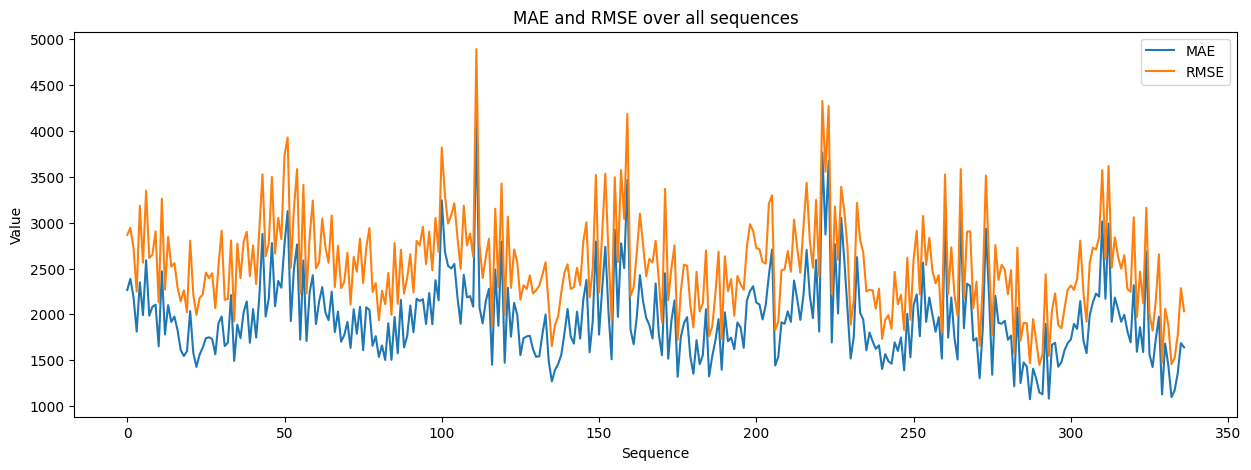

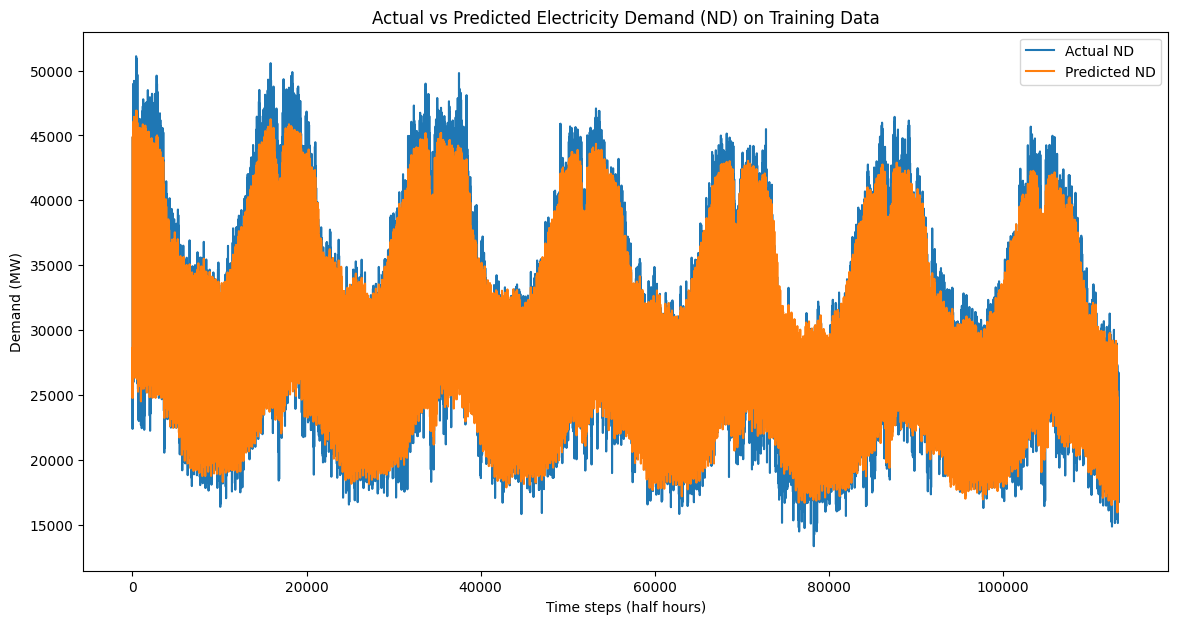

Mean Training MAE and RMSE over first week: 2265.7171921502977, 2866.9665465723524
Mean Training MAE and RMSE over last week: 1640.1945219494048, 2034.61774629577


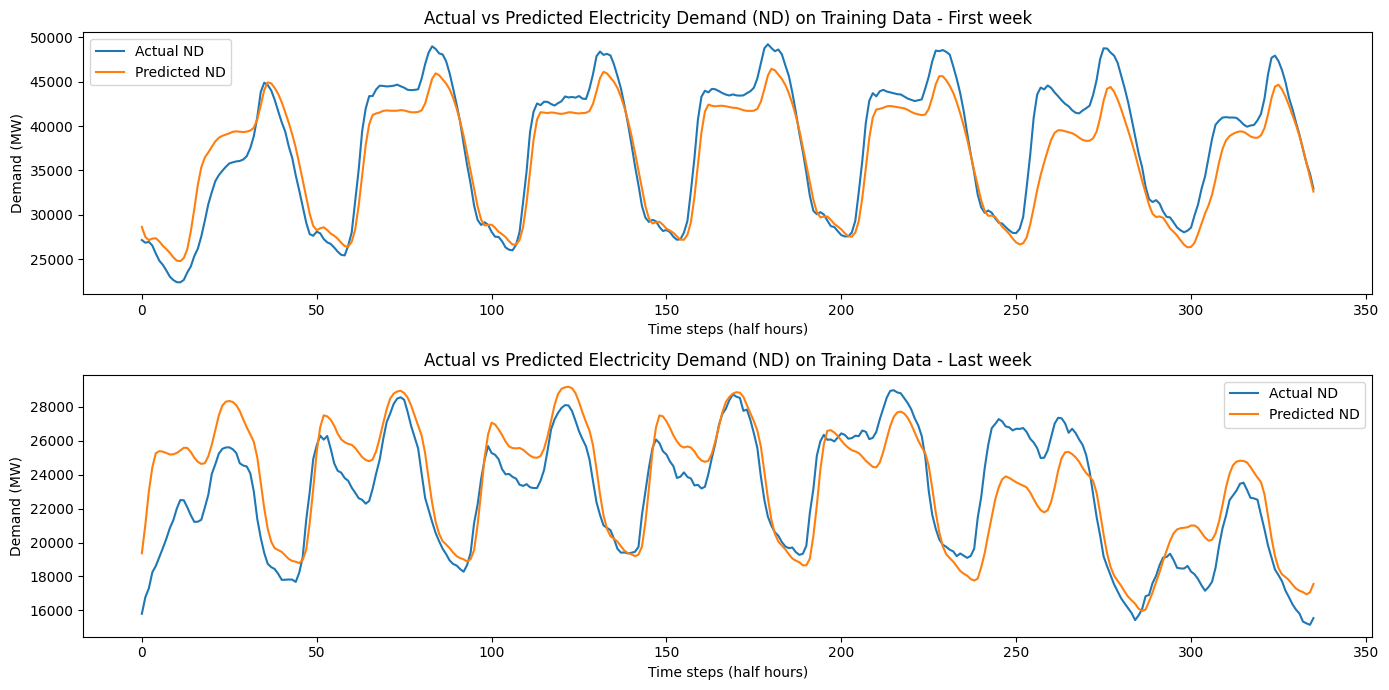

Training predictions for all
Mean Training MAE over all sequences: 2309.698007430265
Mean Training RMSE over all sequences: 3022.3305580541796


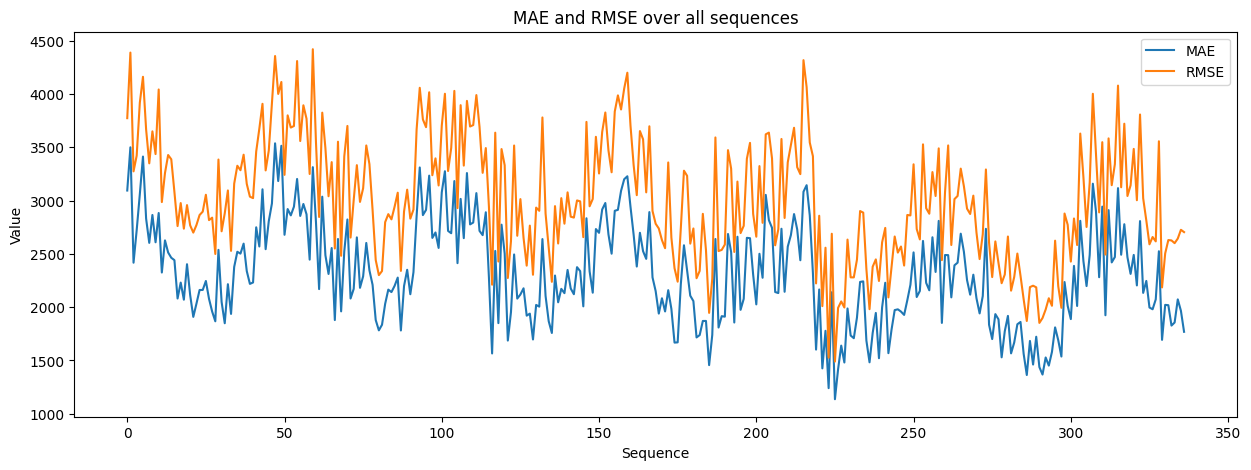

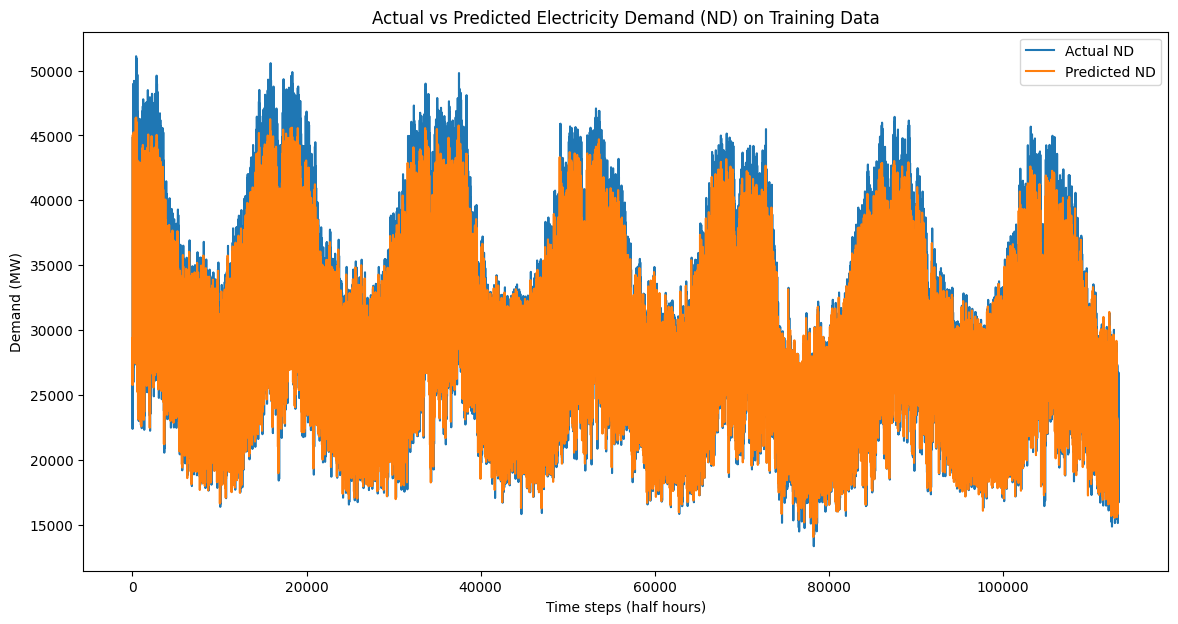

Mean Training MAE and RMSE over first week: 3094.4077962239585, 3773.4758337261355
Mean Training MAE and RMSE over last week: 1768.6059512183779, 2704.1959654307416


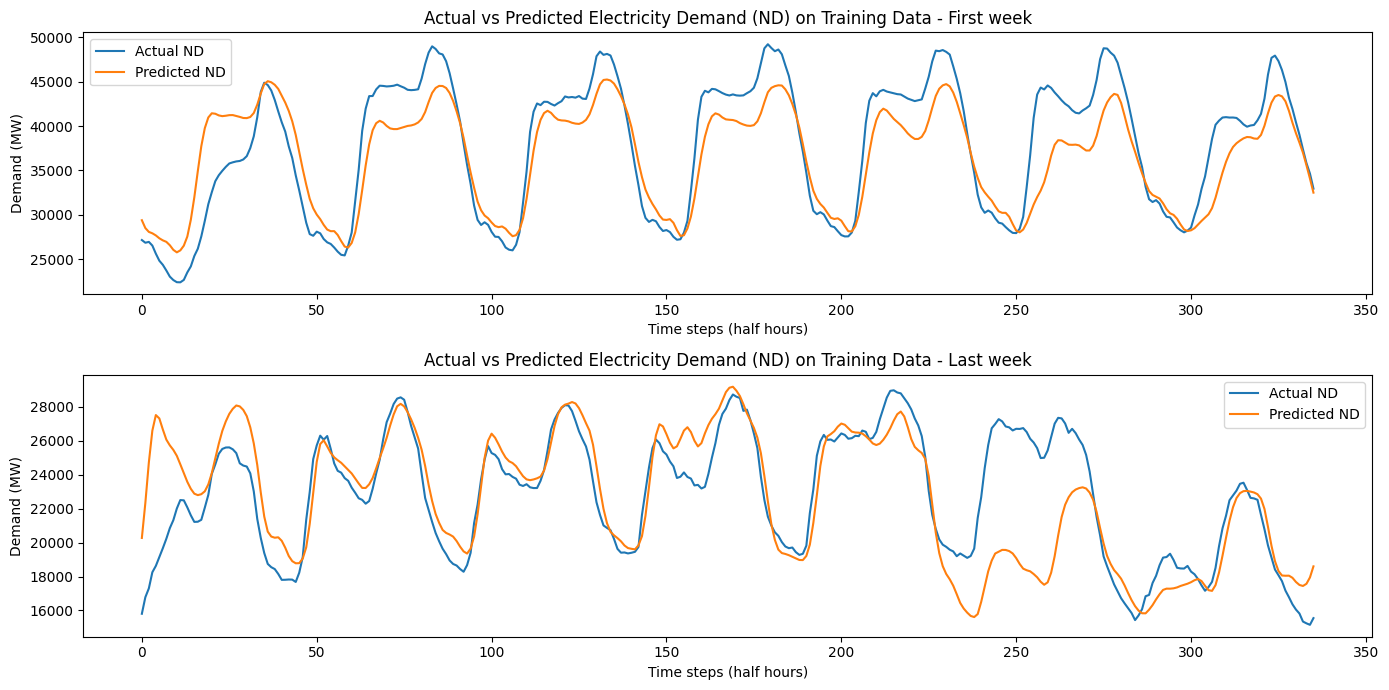

In [ ]:
for config_name, result in results.items():
    model = result["trained_model"]
    train_loader = result["train_loader"]
    y_train = result["y_train"]
    y_scaler = result["y_scaler"]

    print(f"Training predictions for {config_name}")
    train_results = get_train_predictions(model, train_loader, y_train, y_scaler)

    result.update({
        "train_predictions": train_results["train_predictions"],
        "mae_train_mean": train_results["mae_mean"],
        "rmse_train_mean": train_results["rmse_mean"],
        "mae_train_week_first": train_results["mae_first_week"],
        "rmse_train_week_first": train_results["rmse_first_week"],
        "mae_train_week_last": train_results["mae_last_week"],
        "rmse_train_week_last": train_results["rmse_last_week"],
    })

### XGBOOST

All models make **day-ahead direct forecasts**: to predict demand at time t they only use
demand observed up to t − 48 (the lag and rolling features built in notebook 2 are shifted by
48 half-hours). No predictions are fed back in as inputs. XGBoost and MLR see one row of
features per target; the LSTM sees a window of the 48 feature rows ending at the target, and
every demand-based value in that window is also at least 48 steps old. Weather and embedded
generation are observed values (the "perfect weather forecast" assumption).

In [ ]:
import xgboost as xgb

xgb_data_configs = {
    "xgb_full": full,
    "xgb_mrfo": xgb_mrfo,  # XGBoost-fitness MRFO selection
}

xgb_results = {}

for config_name, data in xgb_data_configs.items():
    X = data.drop(columns=["nd"])
    y = data["nd"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    with mlflow.start_run(run_name=config_name):
        params = {
            "n_estimators": 200,
            "max_depth": 6,
            "learning_rate": 0.05,
            "n_jobs": -1,
            "random_state": 42,
        }
        mlflow.log_params({"model_type": "XGBoost", "feature_set": config_name, "n_features": X_train.shape[1], **params})

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        metrics = evaluate(y_test, y_pred, X_test.index)

        mlflow.log_metrics({"mae_test": metrics["mae_test"], "rmse_test": metrics["rmse_test"]})

        mlflow.xgboost.log_model(model, "model")

        xgb_results[config_name] = {
            "model": model, "X_test": X_test, "y_test": y_test, "y_pred": y_pred,
            **metrics,
        }

In [ ]:
for config_name, result in xgb_results.items():
    y_test = result["y_test"]
    y_pred = result["y_pred"]

    fig, axs = plt.subplots(2, 1, figsize=(14, 8))

    axs[0].plot(y_test.to_numpy()[:336], label='Actual ND')
    axs[0].plot(y_pred[:336], label='Predicted ND')
    axs[0].set_title(f'{config_name} — day-ahead forecasts, first week of test period')
    axs[0].set_xlabel('Time steps (half hours)')
    axs[0].set_ylabel('Demand (MW)')
    axs[0].legend()

    axs[1].plot(y_test.to_numpy()[:48], label='Actual ND')
    axs[1].plot(y_pred[:48], label='Predicted ND')
    axs[1].set_title(f'{config_name} — day-ahead forecasts, first day of test period')
    axs[1].set_xlabel('Time steps (half hours)')
    axs[1].set_ylabel('Demand (MW)')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

### SHAP: dependence plot and comparison against both MRFO selections

SHAP importance, computed from the full-feature XGBoost model, gives an independent
check on which features genuinely matter. The temperature dependence plot shows how the
model uses temperature (e.g. heating/cooling nonlinearity), and the comparison table shows
whether the features each MRFO run dropped were genuinely low-importance, or whether the
search missed something SHAP considers relevant. This either validates or challenges MRFO's
feature drops.

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_results["xgb_full"]["model"])
shap_values = explainer.shap_values(xgb_results["xgb_full"]["X_test"])

shap.summary_plot(shap_values, xgb_results["xgb_full"]["X_test"])

In [ ]:
shap.dependence_plot("temperature", shap_values, xgb_results["xgb_full"]["X_test"])

In [ ]:
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=xgb_results["xgb_full"]["X_test"].columns)
shap_importance = shap_importance.sort_values(ascending=False)

comparison = pd.DataFrame({
    "shap_importance": shap_importance,
    "in_xgb_mrfo": shap_importance.index.isin(selected_columns_xgb),
    "in_lstm_mrfo": shap_importance.index.isin(selected_columns_lstm),
})
comparison

### Granger causality: does temperature help predict demand?

This is a separate question from the model comparison. It asks whether past temperature
improves the prediction of demand beyond what demand's own history already provides.
Both series are first-differenced to remove trend and make them closer to stationary.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

test_data = full[['nd', 'temperature']].diff().dropna()
grangercausalitytests(test_data, maxlag=4)

# FORECASTING

### LSTMs

#### Test-set predictions

In [ ]:
for config_name, result in results.items():
    print(f"Test-set predictions for {config_name}")
    test_results = predict_test_set(
        result["trained_model"], result["test_loader"], result["y_test"], result["y_scaler"]
    )

    result["test_predictions"] = test_results["predictions"]
    result.update(evaluate(result["y_test"], result["test_predictions"], result["test_index"]))

    with mlflow.start_run(run_id=result["mlflow_run_id"]):
        mlflow.log_metrics({"mae_test": result["mae_test"], "rmse_test": result["rmse_test"]})

### Multiple Linear Regression

In [ ]:
X_mlr = full.drop(columns=['nd'])
y_mlr = full['nd']

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.2, shuffle=False)

with mlflow.start_run(run_name="mlr_full"):
    mlflow.log_params({
        "model_type": "MLR",
        "feature_set": "full",
        "n_features": X_train_mlr.shape[1],
    })

    model_mlr = LinearRegression()
    model_mlr.fit(X_train_mlr, y_train_mlr)

    y_pred_mlr = model_mlr.predict(X_test_mlr)
    mlr_metrics = evaluate(y_test_mlr, y_pred_mlr, X_test_mlr.index)
    rmse_mlr, mae_mlr = mlr_metrics["rmse_test"], mlr_metrics["mae_test"]

    mlflow.log_metrics({"mae_test": mae_mlr, "rmse_test": rmse_mlr})

    mlflow.sklearn.log_model(model_mlr, "model")

print(f'RMSE/MAE (full test set): {rmse_mlr}, {mae_mlr}')

plt.plot(y_test_mlr[:336].to_numpy(), label='Actual ND')
plt.plot(y_pred_mlr[:336], label='Predicted ND')
plt.title('MLR day-ahead forecasts — first week of test period')
plt.xlabel('Time steps (half hours)')
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()

In [ ]:
p_mlr = [
    rmse_mlr * 100 / y_test_mlr.min(),
    rmse_mlr * 100 / y_test_mlr.max(),
]
p_mlr

# Summary result tables and plots and Wilcoxon test

In [ ]:
# Determine test period indices from the full dataset's test split
test_size = int(len(full) * 0.2)
test_indices = full.index[-test_size:][:336]

colors = {"full": "xkcd:sky blue", "mrfo_lstm": "teal"}

# First week of the test period
plt.figure(figsize=(14, 6))
plt.plot(test_indices, results["full"]["y_test"][:336], color="black", label="Actual (y_test)")
for config_name, result in results.items():
    plt.plot(
        test_indices,
        result["test_predictions"][:336],
        color=colors.get(config_name),
        label=config_name,
    )
plt.title("LSTM day-ahead forecasts — first week of test period")
plt.xlabel("Time steps (half hours)")
plt.ylabel("Demand (MW)")
plt.legend(loc="lower left")
plt.show()

# First day of the test period
plt.figure(figsize=(14, 6))
plt.plot(test_indices[:48], results["full"]["y_test"][:48], color="black", label="Actual (y_test)")
for config_name, result in results.items():
    plt.plot(
        test_indices[:48],
        result["test_predictions"][:48],
        color=colors.get(config_name),
        label=config_name,
    )
plt.title("LSTM day-ahead forecasts — first day of test period")
plt.xlabel("Time steps (half hours)")
plt.ylabel("Demand (MW)")
plt.legend(loc="lower left")
plt.show()

In [ ]:
all_results = {
    **{f"LSTM_{config_name}": result for config_name, result in results.items()},
    **xgb_results,
    "MLR": mlr_metrics,
}

# One column per model, one row per full calendar week of the test period
weekly_rmse = pd.DataFrame({name: r["weekly_rmse"] for name, r in all_results.items()})

comparison_df = pd.DataFrame({
    "mae_test": {name: r["mae_test"] for name, r in all_results.items()},
    "rmse_test": {name: r["rmse_test"] for name, r in all_results.items()},
})
comparison_df["weekly_rmse_median"] = weekly_rmse.median()
comparison_df["weekly_rmse_worst"] = weekly_rmse.max()

# Skill score vs the MLR baseline: 1 - RMSE_model / RMSE_MLR (> 0 means better than MLR)
comparison_df["skill"] = 1 - comparison_df["rmse_test"] / rmse_mlr
# Share of test weeks in which the model's weekly RMSE is below MLR's
comparison_df["weeks_beating_mlr"] = weekly_rmse.lt(weekly_rmse["MLR"], axis=0).mean()

comparison_df.sort_values("rmse_test")

In [ ]:
ax = weekly_rmse.plot(figsize=(14, 6))
ax.set_title("Weekly RMSE across the test period")
ax.set_xlabel("Week")
ax.set_ylabel("RMSE (MW)")
plt.show()

In [ ]:
runs_df = mlflow.search_runs(experiment_names=["energy-demand-forecasting"])
runs_df[["tags.mlflow.runName", "params.feature_set", "metrics.rmse_test", "metrics.mae_test"]]

### Statistical tests: Wilcoxon and Diebold-Mariano

Each model pair is compared with two tests:

- **Wilcoxon signed-rank**: a simple, familiar non-parametric baseline, applied to paired
  absolute errors so it tests which model is more accurate.
- **Diebold-Mariano (DM)**: the standard test in the forecasting literature. It compares the
  loss differential between two forecasts and uses a Newey-West-style long-run variance, so it
  can account for autocorrelation in forecast errors.

`h=48` is used because every forecast is 48 steps (one day) ahead. Errors of h-step-ahead
forecasts are autocorrelated up to lag h − 1 by construction, so the long-run variance uses
47 lags (the function's default of `h - 1`).

In [ ]:
from scipy.stats import norm


def diebold_mariano_test(errors_a, errors_b, h=1, lags=None, power=2):
    """
    h: nominal forecast horizon (for labeling/interpretation)
    lags: number of autocorrelation lags to correct for (Bartlett-weighted
          Newey-West style). Defaults to h-1 if not specified.
    """
    loss_a = np.abs(errors_a) ** power
    loss_b = np.abs(errors_b) ** power
    d = loss_a - loss_b

    if lags is None:
        lags = max(h - 1, 0)

    T = len(d)
    d_mean = np.mean(d)

    gamma_0 = np.var(d, ddof=0)
    gamma_sum = 0
    for lag in range(1, lags + 1):
        weight = 1 - lag / (lags + 1)  # Bartlett weight
        gamma_lag = np.cov(d[lag:], d[:-lag])[0, 1]
        gamma_sum += 2 * weight * gamma_lag
    var_d = (gamma_0 + gamma_sum) / T

    dm_stat = d_mean / np.sqrt(var_d)
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

### Pairwise model comparisons

- **Baseline (MLR vs XGBoost / LSTM):** MLR uses the same features and the same test timestamps,
  but is linear and has no sequence memory. Beating it shows the value of nonlinearity (XGBoost)
  or temporal memory (LSTM) on identical inputs. The different feature handling (no scaling for
  MLR/XGBoost) does not affect the tests: they only compare errors in MW at matched timestamps.
- **Architecture (XGBoost vs LSTM):** both on the full feature set.
- **Feature selection:** whether MRFO improves each model over using all features, and whether
  MRFO's selection differs meaningfully depending on which model it was optimised for.

The tests use the errors over the entire test period (~53k half-hours). They are stored as
timestamp-indexed series and paired with an inner join, so every test compares the same
half-hours. With six tests, p-values are Holm-corrected for multiple comparisons; significance
is judged on the corrected values. With this many points even small differences come out
significant, so read the p-values together with the skill score and `weeks_beating_mlr` in the
comparison table, which show how large and how consistent a difference is.

In [ ]:
from statsmodels.stats.multitest import multipletests

errors = {
    "MLR": mlr_metrics["errors"],
    "XGBoost full": xgb_results["xgb_full"]["errors"],
    "XGBoost mrfo": xgb_results["xgb_mrfo"]["errors"],
    "LSTM full": results["full"]["errors"],
    "LSTM mrfo_lstm": results["mrfo_lstm"]["errors"],
}
n_test = len(errors["MLR"])

comparisons = {
    "Baseline: MLR vs XGBoost full": ("MLR", "XGBoost full"),
    "Baseline: MLR vs LSTM full": ("MLR", "LSTM full"),
    "Architecture: XGBoost full vs LSTM full": ("XGBoost full", "LSTM full"),
    "XGBoost: full vs mrfo": ("XGBoost full", "XGBoost mrfo"),
    "LSTM: full vs mrfo_lstm": ("LSTM full", "LSTM mrfo_lstm"),
    "MRFO comparison: xgb_mrfo vs lstm_mrfo": ("XGBoost mrfo", "LSTM mrfo_lstm"),
}

rows = []
for label, (name_a, name_b) in comparisons.items():
    errors_a, errors_b = errors[name_a].align(errors[name_b], join="inner")
    assert len(errors_a) == n_test, f"{label}: only {len(errors_a)} shared timestamps"

    # Absolute errors: tests accuracy, not whether the errors differ in sign/bias
    w_stat, w_p = wilcoxon(errors_a.abs(), errors_b.abs())
    dm_stat, dm_p = diebold_mariano_test(errors_a.to_numpy(), errors_b.to_numpy(), h=48)
    rows.append({
        "comparison": label,
        "wilcoxon_stat": w_stat, "wilcoxon_p": w_p,
        "dm_stat": dm_stat, "dm_p": dm_p,
    })

tests_df = pd.DataFrame(rows).set_index("comparison")
tests_df["wilcoxon_p_holm"] = multipletests(tests_df["wilcoxon_p"], method="holm")[1]
tests_df["dm_p_holm"] = multipletests(tests_df["dm_p"], method="holm")[1]


def verdict(p_value, alpha=0.05):
    return "significant" if p_value < alpha else "not significant"


for label, row in tests_df.iterrows():
    print(label)
    print(f"  Wilcoxon: statistic={row.wilcoxon_stat:.2f}, p={row.wilcoxon_p:.4f}, p_holm={row.wilcoxon_p_holm:.4f} ({verdict(row.wilcoxon_p_holm)})")
    print(f"  DM:       statistic={row.dm_stat:.2f}, p={row.dm_p:.4f}, p_holm={row.dm_p_holm:.4f} ({verdict(row.dm_p_holm)})")

tests_df